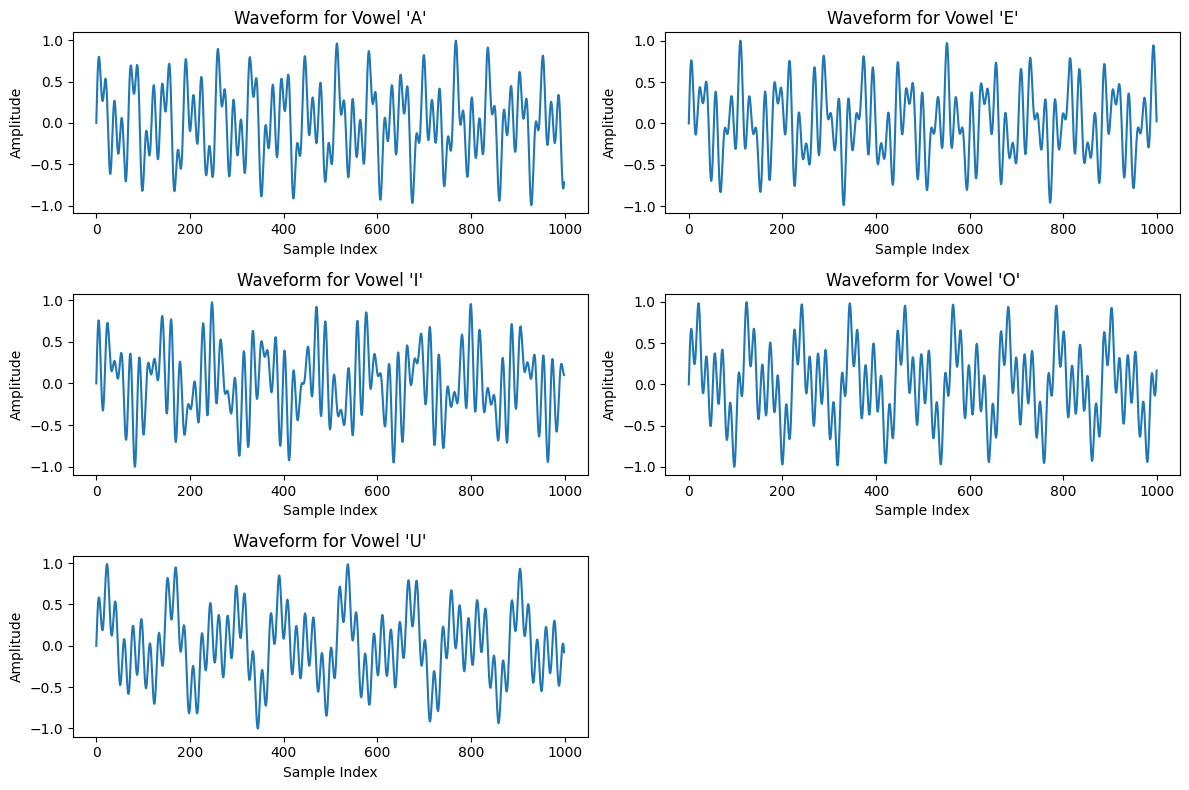

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import chirp
from scipy.signal import butter, lfilter
from IPython.display import Audio

def generate_vowel_waveform(formant_freqs, duration=1.0, sample_rate=44100):
    """
    Generate a synthetic vowel waveform using formant frequencies.
    
    :param formant_freqs: List of formant frequencies for the vowel.
    :param duration: Duration of the vowel sound in seconds.
    :param sample_rate: Sampling rate in Hz.
    :return: Synthetic vowel waveform as a NumPy array.
    """
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    waveform = np.zeros_like(t)
    
    for freq in formant_freqs:
        waveform += np.sin(2 * np.pi * freq * t)
    
    # Apply a simple envelope to mimic natural sound
    envelope = np.exp(-3 * t)  # Exponential decay envelope
    waveform *= envelope
    
    return waveform / np.max(np.abs(waveform))  # Normalize waveform

# Formant frequencies for vowels (in Hz, approximate)
vowel_formants = {
    "A": [700, 1220, 2600],   # e.g., as in "father"
    "E": [500, 1700, 2500],   # e.g., as in "bed"
    "I": [400, 2000, 2550],   # e.g., as in "beet"
    "O": [400, 800, 2600],    # e.g., as in "go"
    "U": [350, 600, 2400]     # e.g., as in "boot"
}

# Generate the wavetable
wavetable = {vowel: generate_vowel_waveform(formants) for vowel, formants in vowel_formants.items()}

# Visualize the waveforms
plt.figure(figsize=(12, 8))
for i, (vowel, waveform) in enumerate(wavetable.items()):
    plt.subplot(3, 2, i + 1)
    plt.plot(waveform[:1000])  # Plot the first 1000 samples
    plt.title(f"Waveform for Vowel '{vowel}'")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Play one of the vowels
Audio(wavetable["U"], rate=44100)
